# 04 · SHAP Explainability & Reason Codes

Loads the trained model and produces SHAP-based, banker-readable reason codes for individual borrowers — the same logic exposed via `src/explainability.py` and used by the FastAPI `/score` endpoint and the Streamlit **Explainability** page.

In [1]:
import sys, os, json
sys.path.insert(0, os.path.join('..', 'src'))
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import shap

from feature_engineering import build_features
from train_model import encode_features, align_columns
from explainability import build_explainer, explain_row

MODELS_DIR = os.path.join('..', 'models')
model = joblib.load(os.path.join(MODELS_DIR, 'trained_model.pkl'))
with open(os.path.join(MODELS_DIR, 'feature_list.json')) as f:
    feature_list = json.load(f)
vectorizer = joblib.load(os.path.join(MODELS_DIR, 'tfidf_vectorizer.pkl'))
text_model = joblib.load(os.path.join(MODELS_DIR, 'text_risk_model.pkl'))
print('Best model:', feature_list['best_model_name'])

Best model: random_forest


/usr/local/lib/python3.11/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Prepare a sample of scored borrowers

In [2]:
raw = pd.read_csv(os.path.join('..', 'data', 'synthetic_msme_data.csv')).sample(300, random_state=3)
engineered, _ = build_features(raw, fit_text_model=False, text_artifacts=(vectorizer, text_model))
X, _ = encode_features(engineered, feature_list['raw_feature_columns'], feature_list['categories'])
X = align_columns(X, feature_list['encoded_columns']).astype(float)
X.shape

(300, 124)

## Global feature importance (mean |SHAP|)

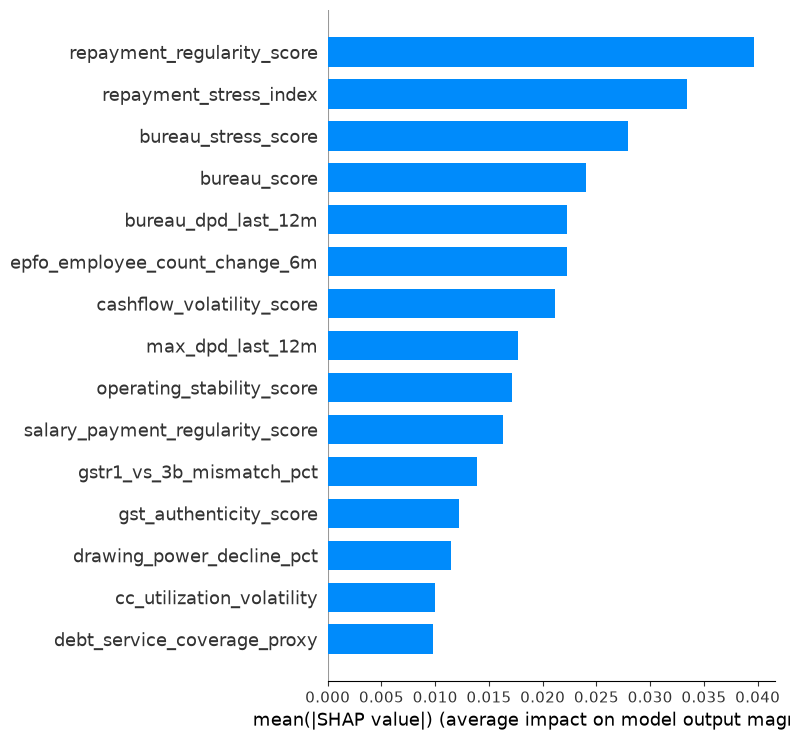

In [3]:
explainer = build_explainer(model)
shap_values = explainer(X)
values = shap_values.values
if values.ndim == 3:
    values = values[:, :, -1]
shap.summary_plot(values, X, plot_type='bar', max_display=15, show=False)
plt.tight_layout()
plt.show()

## Individual borrower explanation → banker reason codes

In [4]:
sample_row = X.iloc[[0]]
borrower_id = engineered.iloc[0]['borrower_id']
result = explain_row(explainer, sample_row, top_n=5)
print('Borrower:', borrower_id)
print(json.dumps(result, indent=2))

Borrower: B101374
{
  "top_risk_drivers": [
    {
      "code": "BUR-SCORE-LOW",
      "description": "Bureau score below policy threshold",
      "impact": 0.0066
    },
    {
      "code": "DSCR-WEAK",
      "description": "Weak debt service coverage proxy",
      "impact": 0.0048
    },
    {
      "code": "GEN-RISK",
      "description": "Outstanding amount contributes to elevated risk",
      "impact": 0.0025
    },
    {
      "code": "SI-ECS-BOUNCE",
      "description": "Standing instruction / ECS bounce observed",
      "impact": 0.0002
    }
  ],
  "top_strength_drivers": [
    {
      "code": "REPAY-CLEAN",
      "description": "Strong repayment regularity",
      "impact": -0.038
    },
    {
      "code": "REPAY-STRONG",
      "description": "Low repayment stress index",
      "impact": -0.0304
    },
    {
      "code": "EPFO-STABLE",
      "description": "Stable / growing employee headcount",
      "impact": -0.026
    },
    {
      "code": "OPS-STABLE",
      "descript

## Waterfall-style view for one borrower

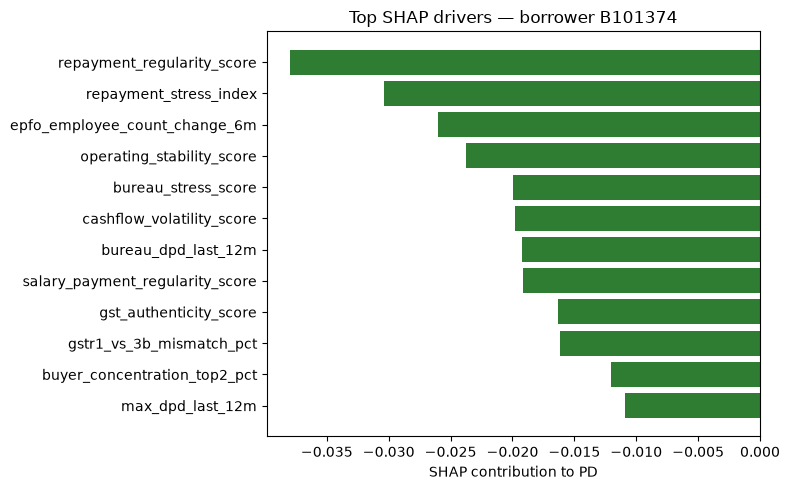

In [5]:
import numpy as np
single = explainer(sample_row)
sv = single.values
if sv.ndim == 3:
    sv = sv[:, :, -1]
order = np.argsort(-np.abs(sv[0]))[:12]
plt.figure(figsize=(8,5))
plt.barh([X.columns[i] for i in order][::-1], sv[0][order][::-1],
         color=['#c62828' if v > 0 else '#2e7d32' for v in sv[0][order][::-1]])
plt.xlabel('SHAP contribution to PD')
plt.title(f'Top SHAP drivers — borrower {borrower_id}')
plt.tight_layout()
plt.show()

## Governance note

SHAP values explain *this* model's *this* prediction — they are a diagnostic and transparency tool for credit officers, not a causal claim about the borrower's true creditworthiness. See `reports/prototype_validation_note.md` and the Governance section of the top-level `README.md` for the human-in-the-loop controls expected before any production use.